Import Dataset

In [0]:
df_spark = spark.table("gold.dataset_ml")
df = df_spark.toPandas()
df = df[df["approved"].notna()].copy()
df["approved"] = df["approved"].astype(int)
# Remove embeddings
emb_features = [c for c in df.columns if c.startswith("emb_")]
df = df.drop(columns=emb_features)

print("Rows:", len(df))
print("\nTarget distribution:")
print(df["approved"].value_counts())
print("\nTarget proportion:")
print(df["approved"].value_counts(normalize=True))
display(df)

Rows: 3694

Target distribution:
approved
1    2529
0    1165
Name: count, dtype: int64

Target proportion:
approved
1    0.684624
0    0.315376
Name: proportion, dtype: float64


study_id,brief_title,approved,degree_total,degree_norm,pagerank_norm,betweenness_norm,closeness_norm,community_louvain,n_conditions,n_countries,n_interventions,n_facilities,n_sponsor_lead,n_sponsor_collaborator,n_sponsors_total,allocation,primary_purpose,intervention_model,masking,is_blinded
NCT01818310,Safety and Efficacy Study of Autologous Bone Marrow Aspirate Concentrate for No-Option Critical Limb Ischemia,1,12.0,0.00933852140077821,0.007804046709532661,0.0013628828854475533,0.6643452811153018,84777,2,1.0,4,1.0,1,2,3,RANDOMIZED,TREATMENT,PARALLEL,QUADRUPLE,1.0
NCT00206401,Lantus in the Treatment of Type 1 Diabetes Children,1,6.0,0.004669260700389105,0.0032851704578695583,7.870525042509487E-4,0.844802582567268,89243,1,1.0,1,1.0,1,1,2,RANDOMIZED,TREATMENT,PARALLEL,NONE,0.0
NCT00563225,20 Week Bridging Study in Type II DM,1,4.0,0.0031128404669260703,0.002093491890224821,1.695066644371339E-4,0.6207432416184481,63747,1,null,1,null,1,1,2,NON_RANDOMIZED,TREATMENT,SINGLE_GROUP,NONE,0.0
NCT01856881,Multiple Ascending Dose Study in Subjects With Type 2 Diabetes,0,11.0,0.008560311284046693,0.006680024999466026,0.0021181178385624205,0.8548934809028691,41719,1,1.0,1,6.0,1,1,2,RANDOMIZED,TREATMENT,PARALLEL,QUADRUPLE,1.0
NCT04027530,"Renal Oxygenation, Oxygen Consumption and Hemodynamic Kinetics in Type 2 DIabetes: an Ertugliflozin Study.",1,12.0,0.00933852140077821,0.006130470474810914,0.0010843903951518244,0.7007978328890712,63747,7,1.0,1,1.0,1,1,2,RANDOMIZED,PREVENTION,CROSSOVER,QUADRUPLE,1.0
NCT03792321,"Study on Effects of Testosterone Replacement Therapy in Hypogonadal Type 2 Diabetic Patients"" (SETH2)",1,7.0,0.005447470817120622,0.0031975232051279375,9.966100920970173E-4,0.7937223250411902,99510,3,null,2,null,1,1,2,RANDOMIZED,TREATMENT,PARALLEL,DOUBLE,1.0
NCT00773279,"Efficacy, Safety and Preference Study of a Insulin Pen PDS290 vs. a Novo Nordisk Marketed Insulin Pen in Diabetics",1,74.0,0.05758754863813229,0.05346524284244794,0.013125113533344128,0.9029757228543955,84501,4,1.0,2,65.0,1,1,2,RANDOMIZED,TREATMENT,CROSSOVER,NONE,0.0
NCT00099619,Comparing Exenatide and Insulin Glargine in Type 2 Diabetes Patients for Whom Insulin is the Next Appropriate Therapy,1,38.0,0.029571984435797664,0.02413862980363765,0.005785645793263939,0.8055204250173579,63747,1,6.0,2,26.0,2,2,4,RANDOMIZED,TREATMENT,CROSSOVER,NONE,0.0
NCT01652729,"Comparison Study of the Glycemic Effects, Safety, and Tolerability of Exenatide Once Weekly Suspension to Sitagliptin and Placebo in Subjects With Type 2 Diabetes Mellitus",1,67.0,0.052140077821011675,0.04923509949619074,0.010637940642438011,0.8667387316080556,45928,1,1.0,3,60.0,1,1,2,RANDOMIZED,TREATMENT,PARALLEL,NONE,0.0
NCT01216618,Evaluation of the Effect of the InsuPatch Device on Insulin Pharmacokinetics in Clamp Studies,1,9.0,0.007003891050583658,0.004861609471439081,8.349748236123763E-4,0.8443093967809915,89130,1,2.0,1,3.0,1,0,1,RANDOMIZED,TREATMENT,CROSSOVER,NONE,0.0


Define fields groups

In [0]:
# Community Louvain Feature
df["community_louvain"] = df["community_louvain"].astype(int)
community_counts = df["community_louvain"].value_counts()
df["community_size"] = df["community_louvain"].map(community_counts).fillna(0)

# Graph Features
graph_features = [
    "degree_total",
    "degree_norm",
    "pagerank_norm",
    "betweenness_norm",
    "closeness_norm",
    "community_size"
]



# Variables BASE
numeric_features_zero = ["n_facilities", "n_countries"]

numeric_features_other = [
    "n_interventions",
    "n_sponsor_lead",
    "n_sponsor_collaborator",
    "n_sponsors_total",
    "n_conditions"
]

categorical_features = [
    "allocation",
    "primary_purpose",
    "masking",
    "intervention_model",
    "is_blinded"
]

text_feature = "brief_title"

df[categorical_features] = df[categorical_features].fillna("UNKNOWN").astype(str)
df[text_feature] = df[text_feature].fillna("").astype(str)

numeric_features_full = (
    numeric_features_zero +
    numeric_features_other +
    graph_features 
)




Define X and y

In [0]:
id_cols = ["study_id"]

y = df["approved"].astype(int)
#Base
X_base = df.drop(
    columns=graph_features  + [text_feature, "approved", "community_louvain"] + id_cols,
    errors="ignore"
)
# Tabular + Text 
X_text = df.drop(
    columns=graph_features  + ["approved", "community_louvain"] + id_cols,
    errors="ignore"
)

# Tabular + Graph
X_graph = df.drop(
    columns=  [text_feature, "approved", "community_louvain"] + id_cols,
    errors="ignore"
)



# Tabular + Text + Graph 
X_graph_text = df.drop(
    columns=["approved", "community_louvain"] + id_cols,
    errors="ignore"
)
print("BASE:", list(X_base.columns))
print("TEXT:", list(X_text.columns))
print("GRAPH:", list(X_graph.columns))

print("FULL:", list(X_graph_text.columns))

BASE: ['n_conditions', 'n_countries', 'n_interventions', 'n_facilities', 'n_sponsor_lead', 'n_sponsor_collaborator', 'n_sponsors_total', 'allocation', 'primary_purpose', 'intervention_model', 'masking', 'is_blinded']
TEXT: ['brief_title', 'n_conditions', 'n_countries', 'n_interventions', 'n_facilities', 'n_sponsor_lead', 'n_sponsor_collaborator', 'n_sponsors_total', 'allocation', 'primary_purpose', 'intervention_model', 'masking', 'is_blinded']
GRAPH: ['degree_total', 'degree_norm', 'pagerank_norm', 'betweenness_norm', 'closeness_norm', 'n_conditions', 'n_countries', 'n_interventions', 'n_facilities', 'n_sponsor_lead', 'n_sponsor_collaborator', 'n_sponsors_total', 'allocation', 'primary_purpose', 'intervention_model', 'masking', 'is_blinded', 'community_size']
FULL: ['brief_title', 'degree_total', 'degree_norm', 'pagerank_norm', 'betweenness_norm', 'closeness_norm', 'n_conditions', 'n_countries', 'n_interventions', 'n_facilities', 'n_sponsor_lead', 'n_sponsor_collaborator', 'n_sponsors

Train/Test

In [0]:
from sklearn.model_selection import train_test_split

# Split data
idx_train, idx_test = train_test_split(
    df.index,
    test_size=0.30,
    random_state=42,
    stratify=y
)


# BASE
X_base_train = X_base.loc[idx_train]
X_base_test  = X_base.loc[idx_test]

# TABULAR + TEXT
X_text_train = X_text.loc[idx_train]
X_text_test  = X_text.loc[idx_test]

# TABULAR + GRAPH

X_graph_train = X_graph.loc[idx_train]
X_graph_test  = X_graph.loc[idx_test]



# FULL
# Tabular + texto + métricas 
X_graph_text_train = X_graph_text.loc[idx_train]
X_graph_text_test  = X_graph_text.loc[idx_test]

# TARGET
y_train = y.loc[idx_train]
y_test  = y.loc[idx_test]

# Trazability
study_train = df.loc[idx_train, "study_id"]
study_test  = df.loc[idx_test, "study_id"]

print("Train size:", len(y_train))
print("Test size:", len(y_test))

print("\nTrain target distribution:")
print(y_train.value_counts(normalize=True))

print("\nTest target distribution:")
print(y_test.value_counts(normalize=True))

Train size: 2585
Test size: 1109

Train target distribution:
approved
1    0.68472
0    0.31528
Name: proportion, dtype: float64

Test target distribution:
approved
1    0.6844
0    0.3156
Name: proportion, dtype: float64


Preprocess

In [0]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd
import numpy as np

text_transformer = Pipeline(steps=[
    ("to_1d", FunctionTransformer(
        lambda x: (
            x.iloc[:, 0]
            if isinstance(x, pd.DataFrame)
            else (x.ravel() if isinstance(x, np.ndarray) else x)
        ).fillna("").astype(str),
        validate=False
    )),
    ("tfidf", TfidfVectorizer(
        max_features=5000,        
        ngram_range=(1, 2),
        min_df=5,                
        max_df=0.8,              
        stop_words="english"
    ))
])

In [0]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# TREE: RF / XGB

preprocess_tree_base = ColumnTransformer(
    transformers=[
        ("num_zero", SimpleImputer(strategy="constant", fill_value=0), numeric_features_zero),
        ("num_other", SimpleImputer(strategy="median"), numeric_features_other),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), categorical_features)
    ],
    remainder="drop",
    sparse_threshold=1.0
)

preprocess_tree_text = ColumnTransformer(
    transformers=[
        ("num_zero", SimpleImputer(strategy="constant", fill_value=0), numeric_features_zero),
        ("num_other", SimpleImputer(strategy="median"), numeric_features_other),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), categorical_features),
        ("text", text_transformer, [text_feature])
    ],
    remainder="drop",
    sparse_threshold=1.0
)

preprocess_tree_graph = ColumnTransformer(
    transformers=[
        ("num_zero", SimpleImputer(strategy="constant", fill_value=0), numeric_features_zero),
        ("num_other", SimpleImputer(strategy="median"),
         numeric_features_other + graph_features ),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), categorical_features)
    ],
    remainder="drop",
    sparse_threshold=1.0
)

preprocess_tree_graph_text = ColumnTransformer(
    transformers=[
        ("num_zero", SimpleImputer(strategy="constant", fill_value=0), numeric_features_zero),
        ("num_other", SimpleImputer(strategy="median"),
         numeric_features_other + graph_features ),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), categorical_features),
        ("text", text_transformer, [text_feature])
    ],
    remainder="drop",
    sparse_threshold=1.0
)

# LINEAR: Logistic Regression / SVM

preprocess_linear_base = ColumnTransformer(
    transformers=[
        ("num_zero", Pipeline([
            ("imputer", SimpleImputer(strategy="constant", fill_value=0)),
            ("scaler", StandardScaler(with_mean=False))
        ]), numeric_features_zero),
        ("num_other", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler(with_mean=False))
        ]), numeric_features_other),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), categorical_features)
    ],
    remainder="drop",
    sparse_threshold=1.0
)

preprocess_linear_text = ColumnTransformer(
    transformers=[
        ("num_zero", Pipeline([
            ("imputer", SimpleImputer(strategy="constant", fill_value=0)),
            ("scaler", StandardScaler(with_mean=False))
        ]), numeric_features_zero),
        ("num_other", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler(with_mean=False))
        ]), numeric_features_other),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), categorical_features),
        ("text", text_transformer, [text_feature])
    ],
    remainder="drop",
    sparse_threshold=1.0
)

preprocess_linear_graph = ColumnTransformer(
    transformers=[
        ("num_zero", Pipeline([
            ("imputer", SimpleImputer(strategy="constant", fill_value=0)),
            ("scaler", StandardScaler(with_mean=False))
        ]), numeric_features_zero),
        ("num_other", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler(with_mean=False))
        ]), numeric_features_other + graph_features ),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), categorical_features)
    ],
    remainder="drop",
    sparse_threshold=1.0
)

preprocess_linear_graph_text = ColumnTransformer(
    transformers=[
        ("num_zero", Pipeline([
            ("imputer", SimpleImputer(strategy="constant", fill_value=0)),
            ("scaler", StandardScaler(with_mean=False))
        ]), numeric_features_zero),
        ("num_other", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler(with_mean=False))
        ]), numeric_features_other + graph_features ),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), categorical_features),
        ("text", text_transformer, [text_feature])
    ],
    remainder="drop",
    sparse_threshold=1.0
)


###Logistic Regresion

Logistic Regression Base

In [0]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    accuracy_score, precision_score, recall_score, f1_score
)
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, StratifiedKFold
import pandas as pd

# CV
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# PIPELINE BASE (solo tabular)
logreg_base_pipe = Pipeline(steps=[
    ("preprocess", preprocess_linear_base),  # 👈 importante: sin texto ni grafo
    ("clf", LogisticRegression(
        max_iter=10000,
        solver="liblinear",
        class_weight="balanced",
        random_state=42
    ))
])

# GRID
param_grid_logreg = [
    {
        "clf__penalty": ["l1", "l2"],
        "clf__C": [0.001, 0.01, 0.1, 1.0, 10.0]
    }
]

grid_logreg_base = GridSearchCV(
    estimator=logreg_base_pipe,
    param_grid=param_grid_logreg,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

# TRAIN (solo 70%)
grid_logreg_base.fit(X_base_train, y_train)

best_logreg_base = grid_logreg_base.best_estimator_

print("Best Logistic Regression BASE params:", grid_logreg_base.best_params_)
print("Best CV f1_macro:", grid_logreg_base.best_score_)

# TEST 
proba_base = best_logreg_base.predict_proba(X_base_test)[:, 1]
pred_base = (proba_base >= 0.5).astype(int)

print("\nLogistic Regression BASE | Test independiente | threshold=0.5")
print(classification_report(y_test, pred_base))
print("Confusion:\n", confusion_matrix(y_test, pred_base))
print("AUC:", roc_auc_score(y_test, proba_base))

# RESULTADOS
logreg_base_test_results = {
    "model": "Logistic Regression",
    "strategy": "BASE (TABULAR ONLY)",
    "best_cv_f1_macro": grid_logreg_base.best_score_,
    "accuracy": accuracy_score(y_test, pred_base),
    "precision_macro": precision_score(y_test, pred_base, average="macro", zero_division=0),
    "recall_macro": recall_score(y_test, pred_base, average="macro", zero_division=0),
    "f1_macro": f1_score(y_test, pred_base, average="macro", zero_division=0),
    "roc_auc": roc_auc_score(y_test, proba_base),
    "best_params": grid_logreg_base.best_params_
}

pd.DataFrame([logreg_base_test_results])

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best Logistic Regression BASE params: {'clf__C': 1.0, 'clf__penalty': 'l1'}
Best CV f1_macro: 0.6459542264064979

Logistic Regression BASE | Test independiente | threshold=0.5
              precision    recall  f1-score   support

           0       0.51      0.51      0.51       350
           1       0.77      0.78      0.78       759

    accuracy                           0.69      1109
   macro avg       0.64      0.64      0.64      1109
weighted avg       0.69      0.69      0.69      1109

Confusion:
 [[178 172]
 [169 590]]
AUC: 0.7110069640504422


,model,strategy,best_cv_f1_macro,accuracy,precision_macro,recall_macro,f1_macro,roc_auc,best_params
0,Logistic Regression,BASE (TABULAR ONLY),0.645954,0.692516,0.643623,0.642955,0.643283,0.711007,"{'clf__C': 1.0, 'clf__penalty': 'l1'}"


Tabular + Text

In [0]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    accuracy_score, precision_score, recall_score, f1_score
)
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, StratifiedKFold
import pandas as pd

# CV
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# PIPELINE (TABULAR + TEXT)
logreg_text_pipe = Pipeline(steps=[
    ("preprocess", preprocess_linear_text),
    ("clf", LogisticRegression(
        max_iter=10000,
        solver="liblinear",
        class_weight="balanced",
        random_state=42
    ))
])

# GRID
param_grid_logreg = {
    "clf__penalty": ["l1", "l2"],
    "clf__C": [0.001, 0.01, 0.1, 1.0, 10.0]
}

grid_logreg_text = GridSearchCV(
    estimator=logreg_text_pipe,
    param_grid=param_grid_logreg,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

# TRAIN 
grid_logreg_text.fit(X_text_train, y_train)

best_logreg_text = grid_logreg_text.best_estimator_

print("Best Logistic Regression TABULAR + TEXT params:", grid_logreg_text.best_params_)
print("Best CV f1_macro:", grid_logreg_text.best_score_)

# TEST 
proba_text = best_logreg_text.predict_proba(X_text_test)[:, 1]
pred_text = (proba_text >= 0.5).astype(int)

print("\nLogistic Regression TABULAR + TEXT | Test independiente | threshold=0.5")
print(classification_report(y_test, pred_text))
print("Confusion:\n", confusion_matrix(y_test, pred_text))
print("AUC:", roc_auc_score(y_test, proba_text))

# RESULTADOS
logreg_text_test_results = {
    "model": "Logistic Regression",
    "strategy": "TABULAR + TEXT",
    "best_cv_f1_macro": grid_logreg_text.best_score_,
    "accuracy": accuracy_score(y_test, pred_text),
    "precision_macro": precision_score(y_test, pred_text, average="macro", zero_division=0),
    "recall_macro": recall_score(y_test, pred_text, average="macro", zero_division=0),
    "f1_macro": f1_score(y_test, pred_text, average="macro", zero_division=0),
    "roc_auc": roc_auc_score(y_test, proba_text),
    "best_params": grid_logreg_text.best_params_
}

pd.DataFrame([logreg_text_test_results])

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best Logistic Regression TABULAR + TEXT params: {'clf__C': 1.0, 'clf__penalty': 'l2'}
Best CV f1_macro: 0.6879079235037111

Logistic Regression TABULAR + TEXT | Test independiente | threshold=0.5
              precision    recall  f1-score   support

           0       0.56      0.67      0.61       350
           1       0.83      0.76      0.79       759

    accuracy                           0.73      1109
   macro avg       0.70      0.71      0.70      1109
weighted avg       0.75      0.73      0.74      1109

Confusion:
 [[233 117]
 [182 577]]
AUC: 0.7924600037643517


,model,strategy,best_cv_f1_macro,accuracy,precision_macro,recall_macro,f1_macro,roc_auc,best_params
0,Logistic Regression,TABULAR + TEXT,0.687908,0.730388,0.696429,0.712963,0.701685,0.79246,"{'clf__C': 1.0, 'clf__penalty': 'l2'}"


Graph

In [0]:
# Logistic Regression - TABULAR + GRAPH

logreg_graph_pipe = Pipeline(steps=[
    ("preprocess", preprocess_linear_graph),
    ("clf", LogisticRegression(
        max_iter=10000,
        solver="liblinear",
        class_weight="balanced",
        random_state=42
    ))
])

param_grid_logreg = {
    "clf__penalty": ["l1", "l2"],
    "clf__C": [0.001, 0.01, 0.1, 1.0, 10.0]
}

grid_logreg_graph = GridSearchCV(
    estimator=logreg_graph_pipe,
    param_grid=param_grid_logreg,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

# TRAIN
grid_logreg_graph.fit(X_graph_train, y_train)

best_logreg_graph = grid_logreg_graph.best_estimator_

print("Best Logistic Regression TABULAR + GRAPH params:", grid_logreg_graph.best_params_)
print("Best CV f1_macro:", grid_logreg_graph.best_score_)

# TEST
proba_graph = best_logreg_graph.predict_proba(X_graph_test)[:, 1]
pred_graph = (proba_graph >= 0.5).astype(int)

print("\nLogistic Regression TABULAR + GRAPH | Test independiente | threshold=0.5")
print(classification_report(y_test, pred_graph))
print("Confusion:\n", confusion_matrix(y_test, pred_graph))
print("AUC:", roc_auc_score(y_test, proba_graph))

# RESULTADOS
logreg_graph_test_results = {
    "model": "Logistic Regression",
    "strategy": "TABULAR + GRAPH",
    "best_cv_f1_macro": grid_logreg_graph.best_score_,
    "accuracy": accuracy_score(y_test, pred_graph),
    "precision_macro": precision_score(y_test, pred_graph, average="macro", zero_division=0),
    "recall_macro": recall_score(y_test, pred_graph, average="macro", zero_division=0),
    "f1_macro": f1_score(y_test, pred_graph, average="macro", zero_division=0),
    "roc_auc": roc_auc_score(y_test, proba_graph),
    "best_params": grid_logreg_graph.best_params_
}

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best Logistic Regression TABULAR + GRAPH params: {'clf__C': 10.0, 'clf__penalty': 'l1'}
Best CV f1_macro: 0.6595719298898678

Logistic Regression TABULAR + GRAPH | Test independiente | threshold=0.5
              precision    recall  f1-score   support

           0       0.52      0.57      0.55       350
           1       0.79      0.76      0.78       759

    accuracy                           0.70      1109
   macro avg       0.66      0.67      0.66      1109
weighted avg       0.71      0.70      0.70      1109

Confusion:
 [[199 151]
 [181 578]]
AUC: 0.7215207980425371


Logistic Regression FULL

In [0]:
# Logistic Regression - TABULAR + TEXT + GRAPH


logreg_graph_text_pipe = Pipeline(steps=[
    ("preprocess", preprocess_linear_graph_text),
    ("clf", LogisticRegression(
        max_iter=10000,
        solver="liblinear",
        class_weight="balanced",
        random_state=42
    ))
])

param_grid_logreg = {
    "clf__penalty": ["l1", "l2"],
    "clf__C": [0.001, 0.01, 0.1, 1.0, 10.0]
}

grid_logreg_graph_text = GridSearchCV(
    estimator=logreg_graph_text_pipe,
    param_grid=param_grid_logreg,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

# CV solo sobre train
grid_logreg_graph_text.fit(X_graph_text_train, y_train)

best_logreg_graph_text = grid_logreg_graph_text.best_estimator_

print("Best Logistic Regression TABULAR + TEXT + GRAPH params:", grid_logreg_graph_text.best_params_)
print("Best CV f1_macro:", grid_logreg_graph_text.best_score_)

# Test independiente
proba_graph_text = best_logreg_graph_text.predict_proba(X_graph_text_test)[:, 1]
pred_graph_text = (proba_graph_text >= 0.5).astype(int)

print("\nLogistic Regression TABULAR + TEXT + GRAPH | Test independiente | threshold=0.5")
print(classification_report(y_test, pred_graph_text))
print("Confusion:\n", confusion_matrix(y_test, pred_graph_text))
print("AUC:", roc_auc_score(y_test, proba_graph_text))

logreg_graph_text_test_results = {
    "model": "Logistic Regression",
    "strategy": "TABULAR + TEXT + GRAPH",
    "best_cv_f1_macro": grid_logreg_graph_text.best_score_,
    "accuracy": accuracy_score(y_test, pred_graph_text),
    "precision_macro": precision_score(y_test, pred_graph_text, average="macro", zero_division=0),
    "recall_macro": recall_score(y_test, pred_graph_text, average="macro", zero_division=0),
    "f1_macro": f1_score(y_test, pred_graph_text, average="macro", zero_division=0),
    "roc_auc": roc_auc_score(y_test, proba_graph_text),
    "best_params": grid_logreg_graph_text.best_params_
}

pd.DataFrame([logreg_graph_text_test_results])

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best Logistic Regression TABULAR + TEXT + GRAPH params: {'clf__C': 1.0, 'clf__penalty': 'l2'}
Best CV f1_macro: 0.7013363369741856

Logistic Regression TABULAR + TEXT + GRAPH | Test independiente | threshold=0.5
              precision    recall  f1-score   support

           0       0.56      0.66      0.61       350
           1       0.83      0.76      0.79       759

    accuracy                           0.73      1109
   macro avg       0.69      0.71      0.70      1109
weighted avg       0.74      0.73      0.73      1109

Confusion:
 [[231 119]
 [182 577]]
AUC: 0.789794842838321


,model,strategy,best_cv_f1_macro,accuracy,precision_macro,recall_macro,f1_macro,roc_auc,best_params
0,Logistic Regression,TABULAR + TEXT + GRAPH,0.701336,0.728584,0.694173,0.710105,0.699316,0.789795,"{'clf__C': 1.0, 'clf__penalty': 'l2'}"


In [0]:
df_lr_comparison = pd.DataFrame([
    logreg_base_test_results,
    logreg_text_test_results,
    logreg_graph_test_results,
    logreg_graph_text_test_results
])

df_lr_comparison.sort_values(by="f1_macro", ascending=False)

,model,strategy,best_cv_f1_macro,accuracy,precision_macro,recall_macro,f1_macro,roc_auc,best_params
1,Logistic Regression,TABULAR + TEXT,0.687908,0.730388,0.696429,0.712963,0.701685,0.792460,"{'clf__C': 1.0, 'clf__penalty': 'l2'}"
3,Logistic Regression,TABULAR + TEXT + GRAPH,0.701336,0.728584,0.694173,0.710105,0.699316,0.789795,"{'clf__C': 1.0, 'clf__penalty': 'l2'}"
2,Logistic Regression,TABULAR + GRAPH,0.659572,0.700631,0.658276,0.665050,0.661044,0.721521,"{'clf__C': 10.0, 'clf__penalty': 'l1'}"
0,Logistic Regression,BASE (TABULAR ONLY),0.645954,0.692516,0.643623,0.642955,0.643283,0.711007,"{'clf__C': 1.0, 'clf__penalty': 'l1'}"


SVM Base

In [0]:
from sklearn.svm import LinearSVC
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    accuracy_score, precision_score, recall_score, f1_score
)
import pandas as pd

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Linear SVM - BASE (TABULAR ONLY)

svm_base_pipe = Pipeline(steps=[
    ("preprocess", preprocess_linear_base),
    ("clf", LinearSVC(
        class_weight="balanced",
        random_state=42,
        max_iter=50000
    ))
])

param_grid_svm = {
    "clf__C": [0.01, 0.1, 1.0, 5.0]
}

grid_svm_base = GridSearchCV(
    estimator=svm_base_pipe,
    param_grid=param_grid_svm,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

# CV solo sobre train
grid_svm_base.fit(X_base_train, y_train)

best_svm_base = grid_svm_base.best_estimator_

print("Best SVM BASE params:", grid_svm_base.best_params_)
print("Best CV f1_macro:", grid_svm_base.best_score_)

# Test independiente
scores_base = best_svm_base.decision_function(X_base_test)
pred_base = (scores_base >= 0).astype(int)

print("\nSVM BASE | Test independiente | threshold=0")
print(classification_report(y_test, pred_base))
print("Confusion:\n", confusion_matrix(y_test, pred_base))
print("AUC:", roc_auc_score(y_test, scores_base))

svm_base_test_results = {
    "model": "Linear SVM",
    "strategy": "BASE (TABULAR ONLY)",
    "best_cv_f1_macro": grid_svm_base.best_score_,
    "accuracy": accuracy_score(y_test, pred_base),
    "precision_macro": precision_score(y_test, pred_base, average="macro", zero_division=0),
    "recall_macro": recall_score(y_test, pred_base, average="macro", zero_division=0),
    "f1_macro": f1_score(y_test, pred_base, average="macro", zero_division=0),
    "roc_auc": roc_auc_score(y_test, scores_base),
    "best_params": grid_svm_base.best_params_
}

pd.DataFrame([svm_base_test_results])

Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best SVM BASE params: {'clf__C': 0.1}
Best CV f1_macro: 0.6462741846320628

SVM BASE | Test independiente | threshold=0
              precision    recall  f1-score   support

           0       0.51      0.51      0.51       350
           1       0.77      0.78      0.78       759

    accuracy                           0.69      1109
   macro avg       0.64      0.64      0.64      1109
weighted avg       0.69      0.69      0.69      1109

Confusion:
 [[177 173]
 [169 590]]
AUC: 0.7087182382834557


,model,strategy,best_cv_f1_macro,accuracy,precision_macro,recall_macro,f1_macro,roc_auc,best_params
0,Linear SVM,BASE (TABULAR ONLY),0.646274,0.691614,0.642412,0.641526,0.641958,0.708718,{'clf__C': 0.1}


Text

In [0]:
from sklearn.svm import LinearSVC
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    accuracy_score, precision_score, recall_score, f1_score
)
import pandas as pd

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

svm_text_pipe = Pipeline(steps=[
    ("preprocess", preprocess_linear_text),
    ("clf", LinearSVC(
        class_weight="balanced",
        random_state=42,
        max_iter=50000
    ))
])

param_grid_svm = {
    "clf__C": [0.01, 0.1, 1.0, 5.0]
}

grid_svm_text = GridSearchCV(
    estimator=svm_text_pipe,
    param_grid=param_grid_svm,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_svm_text.fit(X_text_train, y_train)

best_svm_text = grid_svm_text.best_estimator_

print("Best SVM TABULAR + TEXT params:", grid_svm_text.best_params_)
print("Best CV f1_macro:", grid_svm_text.best_score_)

scores_text = best_svm_text.decision_function(X_text_test)
pred_text = (scores_text >= 0).astype(int)

print("\nSVM TABULAR + TEXT | Test independiente | threshold=0")
print(classification_report(y_test, pred_text))
print("Confusion:\n", confusion_matrix(y_test, pred_text))
print("AUC:", roc_auc_score(y_test, scores_text))

svm_text_test_results = {
    "model": "Linear SVM",
    "strategy": "TABULAR + TEXT",
    "best_cv_f1_macro": grid_svm_text.best_score_,
    "accuracy": accuracy_score(y_test, pred_text),
    "precision_macro": precision_score(y_test, pred_text, average="macro", zero_division=0),
    "recall_macro": recall_score(y_test, pred_text, average="macro", zero_division=0),
    "f1_macro": f1_score(y_test, pred_text, average="macro", zero_division=0),
    "roc_auc": roc_auc_score(y_test, scores_text),
    "best_params": grid_svm_text.best_params_
}

pd.DataFrame([svm_text_test_results])

Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best SVM TABULAR + TEXT params: {'clf__C': 0.1}
Best CV f1_macro: 0.6913130810207779

SVM TABULAR + TEXT | Test independiente | threshold=0
              precision    recall  f1-score   support

           0       0.56      0.66      0.61       350
           1       0.83      0.76      0.79       759

    accuracy                           0.73      1109
   macro avg       0.70      0.71      0.70      1109
weighted avg       0.75      0.73      0.74      1109

Confusion:
 [[232 118]
 [181 578]]
AUC: 0.7917673630717109


,model,strategy,best_cv_f1_macro,accuracy,precision_macro,recall_macro,f1_macro,roc_auc,best_params
0,Linear SVM,TABULAR + TEXT,0.691313,0.730388,0.696102,0.712193,0.701314,0.791767,{'clf__C': 0.1}


Graph

In [0]:
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    accuracy_score, precision_score, recall_score, f1_score
)
import pandas as pd

# Linear SVM - TABULAR + GRAPH

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

svm_graph_pipe = Pipeline(steps=[
    ("preprocess", preprocess_linear_graph),
    ("clf", LinearSVC(
        class_weight="balanced",
        random_state=42,
        max_iter=50000
    ))
])

param_grid_svm = {
    "clf__C": [0.01, 0.1, 1.0, 5.0]
}

grid_svm_graph = GridSearchCV(
    estimator=svm_graph_pipe,
    param_grid=param_grid_svm,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

# CV solo sobre train
grid_svm_graph.fit(X_graph_train, y_train)

best_svm_graph = grid_svm_graph.best_estimator_

print("Best SVM TABULAR + GRAPH params:", grid_svm_graph.best_params_)
print("Best SVM TABULAR + GRAPH CV f1_macro:", grid_svm_graph.best_score_)

# Evaluación en test independiente
scores_svm_graph = best_svm_graph.decision_function(X_graph_test)
pred_svm_graph = (scores_svm_graph >= 0).astype(int)

print("\nSVM TABULAR + GRAPH | Test independiente | threshold=0")
print(classification_report(y_test, pred_svm_graph))
print("Confusion:\n", confusion_matrix(y_test, pred_svm_graph))
print("AUC:", roc_auc_score(y_test, scores_svm_graph))

svm_graph_test_results = {
    "model": "Linear SVM",
    "strategy": "TABULAR + GRAPH",
    "best_cv_f1_macro": grid_svm_graph.best_score_,
    "accuracy": accuracy_score(y_test, pred_svm_graph),
    "precision_macro": precision_score(y_test, pred_svm_graph, average="macro", zero_division=0),
    "recall_macro": recall_score(y_test, pred_svm_graph, average="macro", zero_division=0),
    "f1_macro": f1_score(y_test, pred_svm_graph, average="macro", zero_division=0),
    "roc_auc": roc_auc_score(y_test, scores_svm_graph),
    "best_params": grid_svm_graph.best_params_
}

pd.DataFrame([svm_graph_test_results])

Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best SVM TABULAR + GRAPH params: {'clf__C': 5.0}
Best SVM TABULAR + GRAPH CV f1_macro: 0.6592642349352433

SVM TABULAR + GRAPH | Test independiente | threshold=0
              precision    recall  f1-score   support

           0       0.53      0.56      0.54       350
           1       0.79      0.77      0.78       759

    accuracy                           0.71      1109
   macro avg       0.66      0.67      0.66      1109
weighted avg       0.71      0.71      0.71      1109

Confusion:
 [[195 155]
 [171 588]]
AUC: 0.7195143986448334


,model,strategy,best_cv_f1_macro,accuracy,precision_macro,recall_macro,f1_macro,roc_auc,best_params
0,Linear SVM,TABULAR + GRAPH,0.659264,0.706041,0.662087,0.665923,0.663824,0.719514,{'clf__C': 5.0}


Full

In [0]:
# Linear SVM - TABULAR + TEXT + GRAPH
# CV sobre train / evaluación final sobre test independiente

svm_graph_text_pipe = Pipeline(steps=[
    ("preprocess", preprocess_linear_graph_text),
    ("clf", LinearSVC(
        class_weight="balanced",
        random_state=42,
        max_iter=50000
    ))
])

grid_svm_graph_text = GridSearchCV(
    estimator=svm_graph_text_pipe,
    param_grid=param_grid_svm,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

# CV solo sobre train
grid_svm_graph_text.fit(X_graph_text_train, y_train)

best_svm_graph_text = grid_svm_graph_text.best_estimator_

print("Best SVM TABULAR + TEXT + GRAPH params:", grid_svm_graph_text.best_params_)
print("Best CV f1_macro:", grid_svm_graph_text.best_score_)

# Evaluación final sobre test independiente
scores_graph_text = best_svm_graph_text.decision_function(X_graph_text_test)
pred_graph_text = (scores_graph_text >= 0).astype(int)

print("\nSVM TABULAR + TEXT + GRAPH | Test independiente | threshold=0")
print(classification_report(y_test, pred_graph_text))
print("Confusion:\n", confusion_matrix(y_test, pred_graph_text))
print("AUC:", roc_auc_score(y_test, scores_graph_text))

svm_graph_text_test_results = {
    "model": "Linear SVM",
    "strategy": "TABULAR + TEXT + GRAPH",
    "best_cv_f1_macro": grid_svm_graph_text.best_score_,
    "accuracy": accuracy_score(y_test, pred_graph_text),
    "precision_macro": precision_score(y_test, pred_graph_text, average="macro", zero_division=0),
    "recall_macro": recall_score(y_test, pred_graph_text, average="macro", zero_division=0),
    "f1_macro": f1_score(y_test, pred_graph_text, average="macro", zero_division=0),
    "roc_auc": roc_auc_score(y_test, scores_graph_text),
    "best_params": grid_svm_graph_text.best_params_
}

pd.DataFrame([svm_graph_text_test_results])

Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best SVM TABULAR + TEXT + GRAPH params: {'clf__C': 0.1}
Best CV f1_macro: 0.7049575078926859

SVM TABULAR + TEXT + GRAPH | Test independiente | threshold=0
              precision    recall  f1-score   support

           0       0.57      0.67      0.61       350
           1       0.83      0.76      0.80       759

    accuracy                           0.73      1109
   macro avg       0.70      0.72      0.71      1109
weighted avg       0.75      0.73      0.74      1109

Confusion:
 [[234 116]
 [179 580]]
AUC: 0.7892377188029361


,model,strategy,best_cv_f1_macro,accuracy,precision_macro,recall_macro,f1_macro,roc_auc,best_params
0,Linear SVM,TABULAR + TEXT + GRAPH,0.704958,0.733995,0.69996,0.716367,0.70531,0.789238,{'clf__C': 0.1}


In [0]:
df_svm_comparison = pd.DataFrame([
    svm_base_test_results,
    svm_text_test_results,
    svm_graph_test_results,
    svm_graph_text_test_results
])

df_svm_comparison.sort_values(by="f1_macro", ascending=False)

,model,strategy,best_cv_f1_macro,accuracy,precision_macro,recall_macro,f1_macro,roc_auc,best_params
3,Linear SVM,TABULAR + TEXT + GRAPH,0.704958,0.733995,0.699960,0.716367,0.705310,0.789238,{'clf__C': 0.1}
1,Linear SVM,TABULAR + TEXT,0.691313,0.730388,0.696102,0.712193,0.701314,0.791767,{'clf__C': 0.1}
2,Linear SVM,TABULAR + GRAPH,0.659264,0.706041,0.662087,0.665923,0.663824,0.719514,{'clf__C': 5.0}
0,Linear SVM,BASE (TABULAR ONLY),0.646274,0.691614,0.642412,0.641526,0.641958,0.708718,{'clf__C': 0.1}


Rnadom Forest

Base

In [0]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    accuracy_score, precision_score, recall_score, f1_score
)
import pandas as pd


cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


rf_base_pipe = Pipeline(steps=[
    ("preprocess", preprocess_tree_base),  
    ("clf", RandomForestClassifier(
        random_state=42,
        n_jobs=-1,
        class_weight="balanced"
    ))
])
param_grid_rf = {
    "clf__n_estimators": [300,500],
    "clf__max_depth": [10, 20,None],
    "clf__min_samples_leaf": [1, 3,5],
    "clf__max_features": ["sqrt", 0.3],
}

grid_rf_base = GridSearchCV(
    estimator=rf_base_pipe,
    param_grid=param_grid_rf,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    verbose=1
)


grid_rf_base.fit(X_base_train, y_train)

best_rf_base = grid_rf_base.best_estimator_

print("Best RF BASE params:", grid_rf_base.best_params_)
print("Best CV f1_macro:", grid_rf_base.best_score_)


proba_base = best_rf_base.predict_proba(X_base_test)[:, 1]
pred_base = (proba_base >= 0.5).astype(int)

print("\nRandom Forest BASE | Test independiente | threshold=0.5")
print(classification_report(y_test, pred_base))
print("Confusion:\n", confusion_matrix(y_test, pred_base))
print("AUC:", roc_auc_score(y_test, proba_base))


rf_base_test_results = {
    "model": "Random Forest",
    "strategy": "BASE (TABULAR ONLY)",
    "best_cv_f1_macro": grid_rf_base.best_score_,
    "accuracy": accuracy_score(y_test, pred_base),
    "precision_macro": precision_score(y_test, pred_base, average="macro", zero_division=0),
    "recall_macro": recall_score(y_test, pred_base, average="macro", zero_division=0),
    "f1_macro": f1_score(y_test, pred_base, average="macro", zero_division=0),
    "roc_auc": roc_auc_score(y_test, proba_base),
    "best_params": grid_rf_base.best_params_
}

pd.DataFrame([rf_base_test_results])

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best RF BASE params: {'clf__max_depth': 10, 'clf__max_features': 0.3, 'clf__min_samples_leaf': 3, 'clf__n_estimators': 300}
Best CV f1_macro: 0.6517929629862317

Random Forest BASE | Test independiente | threshold=0.5
              precision    recall  f1-score   support

           0       0.54      0.57      0.56       350
           1       0.80      0.77      0.79       759

    accuracy                           0.71      1109
   macro avg       0.67      0.67      0.67      1109
weighted avg       0.72      0.71      0.71      1109

Confusion:
 [[201 149]
 [172 587]]
AUC: 0.7443967626576322


,model,strategy,best_cv_f1_macro,accuracy,precision_macro,recall_macro,f1_macro,roc_auc,best_params
0,Random Forest,BASE (TABULAR ONLY),0.651793,0.71055,0.668214,0.673836,0.67065,0.744397,"{'clf__max_depth': 10, 'clf__max_features': 0...."


Text

In [0]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    accuracy_score, precision_score, recall_score, f1_score
)
import pandas as pd

cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf_text_pipe = Pipeline(steps=[
    ("preprocess", preprocess_tree_text),
    ("clf", RandomForestClassifier(
        random_state=42,
        n_jobs=-1,
        class_weight="balanced"
    ))
])

param_grid_rf_text = {
    "clf__n_estimators": [200, 300, 400],
    "clf__max_depth": [None],
    "clf__min_samples_leaf": [2, 3, 4],
    "clf__max_features": ["sqrt"],
}

grid_rf_text = GridSearchCV(
    estimator=rf_text_pipe,
    param_grid=param_grid_rf_text,
    scoring="f1_macro",
    cv=cv5,
    n_jobs=1,
    verbose=1
)

grid_rf_text.fit(X_text_train, y_train)

best_rf_text = grid_rf_text.best_estimator_

print("Best RF TABULAR + TEXT params:", grid_rf_text.best_params_)
print("Best RF TABULAR + TEXT CV f1_macro:", grid_rf_text.best_score_)

proba_text = best_rf_text.predict_proba(X_text_test)[:, 1]
pred_text = (proba_text >= 0.5).astype(int)

print("\nRandom Forest TABULAR + TEXT | Test independiente | threshold=0.5")
print(classification_report(y_test, pred_text))
print("Confusion:\n", confusion_matrix(y_test, pred_text))
print("AUC:", roc_auc_score(y_test, proba_text))

rf_text_test_results = {
    "model": "Random Forest",
    "strategy": "TABULAR + TEXT",
    "best_cv_f1_macro": grid_rf_text.best_score_,
    "accuracy": accuracy_score(y_test, pred_text),
    "precision_macro": precision_score(y_test, pred_text, average="macro", zero_division=0),
    "recall_macro": recall_score(y_test, pred_text, average="macro", zero_division=0),
    "f1_macro": f1_score(y_test, pred_text, average="macro", zero_division=0),
    "roc_auc": roc_auc_score(y_test, proba_text),
    "best_params": grid_rf_text.best_params_
}

pd.DataFrame([rf_text_test_results])

Fitting 5 folds for each of 9 candidates, totalling 45 fits
Best RF TABULAR + TEXT params: {'clf__max_depth': None, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 2, 'clf__n_estimators': 400}
Best RF TABULAR + TEXT CV f1_macro: 0.686057568768004

Random Forest TABULAR + TEXT | Test independiente | threshold=0.5
              precision    recall  f1-score   support

           0       0.61      0.62      0.61       350
           1       0.82      0.81      0.82       759

    accuracy                           0.75      1109
   macro avg       0.71      0.72      0.72      1109
weighted avg       0.75      0.75      0.75      1109

Confusion:
 [[217 133]
 [141 618]]
AUC: 0.810223978919631


,model,strategy,best_cv_f1_macro,accuracy,precision_macro,recall_macro,f1_macro,roc_auc,best_params
0,Random Forest,TABULAR + TEXT,0.686058,0.752931,0.714524,0.717115,0.715769,0.810224,"{'clf__max_depth': None, 'clf__max_features': ..."


Graph 

In [0]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    accuracy_score, precision_score, recall_score, f1_score
)
import pandas as pd

# Random Forest - TABULAR + GRAPH

cv5 = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

rf_graph_pipe = Pipeline(steps=[
    ("preprocess", preprocess_tree_graph),
    ("clf", RandomForestClassifier(
        random_state=42,
        n_jobs=-1,
        class_weight="balanced"
    ))
])

param_grid_rf_graph = {
    "clf__n_estimators": [300, 500],
    "clf__max_depth": [8, 10, 15, None],
    "clf__min_samples_leaf": [1, 3, 5],
    "clf__max_features": ["sqrt", 0.5],
}

grid_rf_graph = GridSearchCV(
    estimator=rf_graph_pipe,
    param_grid=param_grid_rf_graph,
    scoring="f1_macro",
    cv=cv5,
    n_jobs=1,
    verbose=1
)

# CV solo sobre train
grid_rf_graph.fit(X_graph_train, y_train)

best_rf_graph = grid_rf_graph.best_estimator_

print("Best RF TABULAR + GRAPH params:", grid_rf_graph.best_params_)
print("Best RF TABULAR + GRAPH CV f1_macro:", grid_rf_graph.best_score_)

# Evaluación final en test independiente
proba_graph = best_rf_graph.predict_proba(X_graph_test)[:, 1]
pred_graph = (proba_graph >= 0.5).astype(int)

print("\nRandom Forest TABULAR + GRAPH | Test independiente | threshold=0.5")
print(classification_report(y_test, pred_graph))
print("Confusion:\n", confusion_matrix(y_test, pred_graph))
print("AUC:", roc_auc_score(y_test, proba_graph))

rf_graph_test_results = {
    "model": "Random Forest",
    "strategy": "TABULAR + GRAPH",
    "best_cv_f1_macro": grid_rf_graph.best_score_,
    "accuracy": accuracy_score(y_test, pred_graph),
    "precision_macro": precision_score(y_test, pred_graph, average="macro", zero_division=0),
    "recall_macro": recall_score(y_test, pred_graph, average="macro", zero_division=0),
    "f1_macro": f1_score(y_test, pred_graph, average="macro", zero_division=0),
    "roc_auc": roc_auc_score(y_test, proba_graph),
    "best_params": grid_rf_graph.best_params_
}

pd.DataFrame([rf_graph_test_results])

Fitting 5 folds for each of 48 candidates, totalling 240 fits
Best RF TABULAR + GRAPH params: {'clf__max_depth': 15, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 5, 'clf__n_estimators': 300}
Best RF TABULAR + GRAPH CV f1_macro: 0.6842928043258825

Random Forest TABULAR + GRAPH | Test independiente | threshold=0.5
              precision    recall  f1-score   support

           0       0.61      0.62      0.61       350
           1       0.82      0.81      0.82       759

    accuracy                           0.75      1109
   macro avg       0.71      0.72      0.72      1109
weighted avg       0.75      0.75      0.75      1109

Confusion:
 [[218 132]
 [142 617]]
AUC: 0.7915753811405984


,model,strategy,best_cv_f1_macro,accuracy,precision_macro,recall_macro,f1_macro,roc_auc,best_params
0,Random Forest,TABULAR + GRAPH,0.684293,0.752931,0.71466,0.717884,0.716193,0.791575,"{'clf__max_depth': 15, 'clf__max_features': 's..."


Full

In [0]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    accuracy_score, precision_score, recall_score, f1_score
)
import pandas as pd

cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf_graph_text_pipe = Pipeline(steps=[
    ("preprocess", preprocess_tree_graph_text),
    ("clf", RandomForestClassifier(
        random_state=42,
        n_jobs=-1,
        class_weight="balanced_subsample"
    ))
])

param_grid_rf_graph_text = {
    "clf__n_estimators": [300, 500],
    "clf__max_depth": [8, 10, 15],
    "clf__min_samples_leaf": [3, 5, 10],
    "clf__max_features": ["sqrt", 0.5],
}

grid_rf_graph_text = GridSearchCV(
    estimator=rf_graph_text_pipe,
    param_grid=param_grid_rf_graph_text,
    scoring="f1_macro",
    cv=cv5,
    n_jobs=1,
    verbose=1
)

# CV solo sobre train
grid_rf_graph_text.fit(X_graph_text_train, y_train)

best_rf_graph_text = grid_rf_graph_text.best_estimator_

print("Best RF TABULAR + TEXT + GRAPH params:", grid_rf_graph_text.best_params_)
print("Best RF TABULAR + TEXT + GRAPH CV f1_macro:", grid_rf_graph_text.best_score_)

# Test independiente
proba_graph_text = best_rf_graph_text.predict_proba(X_graph_text_test)[:, 1]
pred_graph_text = (proba_graph_text >= 0.5).astype(int)

print("\nRandom Forest TABULAR + TEXT + GRAPH | Test independiente | threshold=0.5")
print(classification_report(y_test, pred_graph_text))
print("Confusion:\n", confusion_matrix(y_test, pred_graph_text))
print("AUC:", roc_auc_score(y_test, proba_graph_text))

rf_graph_text_test_results = {
    "model": "Random Forest",
    "strategy": "TABULAR + TEXT + GRAPH",
    "best_cv_f1_macro": grid_rf_graph_text.best_score_,
    "accuracy": accuracy_score(y_test, pred_graph_text),
    "precision_macro": precision_score(y_test, pred_graph_text, average="macro", zero_division=0),
    "recall_macro": recall_score(y_test, pred_graph_text, average="macro", zero_division=0),
    "f1_macro": f1_score(y_test, pred_graph_text, average="macro", zero_division=0),
    "roc_auc": roc_auc_score(y_test, proba_graph_text),
    "best_params": grid_rf_graph_text.best_params_
}

pd.DataFrame([rf_graph_text_test_results])

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best RF TABULAR + TEXT + GRAPH params: {'clf__max_depth': 15, 'clf__max_features': 0.5, 'clf__min_samples_leaf': 3, 'clf__n_estimators': 300}
Best RF TABULAR + TEXT + GRAPH CV f1_macro: 0.6989995312880143

Random Forest TABULAR + TEXT + GRAPH | Test independiente | threshold=0.5
              precision    recall  f1-score   support

           0       0.66      0.58      0.62       350
           1       0.82      0.86      0.84       759

    accuracy                           0.77      1109
   macro avg       0.74      0.72      0.73      1109
weighted avg       0.77      0.77      0.77      1109

Confusion:
 [[202 148]
 [103 656]]
AUC: 0.828722002635046


,model,strategy,best_cv_f1_macro,accuracy,precision_macro,recall_macro,f1_macro,roc_auc,best_params
0,Random Forest,TABULAR + TEXT + GRAPH,0.699,0.77367,0.739108,0.720719,0.728103,0.828722,"{'clf__max_depth': 15, 'clf__max_features': 0...."


In [0]:
df_rf_comparison = pd.DataFrame([
    rf_base_test_results,
    rf_text_test_results,
    rf_graph_test_results,
    rf_graph_text_test_results
])

df_rf_comparison.sort_values(by="f1_macro", ascending=False)

,model,strategy,best_cv_f1_macro,accuracy,precision_macro,recall_macro,f1_macro,roc_auc,best_params
3,Random Forest,TABULAR + TEXT + GRAPH,0.699000,0.773670,0.739108,0.720719,0.728103,0.828722,"{'clf__max_depth': 15, 'clf__max_features': 0...."
2,Random Forest,TABULAR + GRAPH,0.684293,0.752931,0.714660,0.717884,0.716193,0.791575,"{'clf__max_depth': 15, 'clf__max_features': 's..."
1,Random Forest,TABULAR + TEXT,0.686058,0.752931,0.714524,0.717115,0.715769,0.810224,"{'clf__max_depth': None, 'clf__max_features': ..."
0,Random Forest,BASE (TABULAR ONLY),0.651793,0.710550,0.668214,0.673836,0.670650,0.744397,"{'clf__max_depth': 10, 'clf__max_features': 0...."


XGBOOST

In [0]:
%pip install xgboost

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


Base

In [0]:
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    accuracy_score, precision_score, recall_score, f1_score
)
from scipy.stats import randint, uniform
import pandas as pd

# scale_pos_weight (solo train)
pos = float((y_train == 1).sum())
neg = float((y_train == 0).sum())
spw_base = neg / max(pos, 1.0)

# PIPELINE BASE
xgb_base_pipe = Pipeline(steps=[
    ("preprocess", preprocess_tree_base),  
    ("clf", XGBClassifier(
        objective="binary:logistic",
        eval_metric="auc",
        tree_method="hist",
        random_state=42,
        n_jobs=-1
    ))
])

# RANDOM SEARCH
param_dist_xgb_base = {
    "clf__n_estimators": randint(200, 600),
    "clf__max_depth": randint(3, 7),
    "clf__learning_rate": uniform(0.02, 0.10),
    "clf__subsample": uniform(0.65, 0.35),
    "clf__colsample_bytree": uniform(0.65, 0.35),
    "clf__min_child_weight": randint(1, 10),
    "clf__gamma": uniform(0.0, 2.0),
    "clf__reg_lambda": uniform(0.5, 15.0),
    "clf__reg_alpha": uniform(0.0, 2.0),
    "clf__scale_pos_weight": [1.0, spw_base],
}

cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rand_xgb_base = RandomizedSearchCV(
    estimator=xgb_base_pipe,
    param_distributions=param_dist_xgb_base,
    n_iter=40,
    scoring="f1_macro",
    cv=cv5,
    verbose=1,
    n_jobs=1,
    random_state=42
)

# TRAIN
rand_xgb_base.fit(X_base_train, y_train)

best_xgb_base = rand_xgb_base.best_estimator_

print("Best XGB BASE params:", rand_xgb_base.best_params_)
print("Best XGB BASE CV f1_macro:", rand_xgb_base.best_score_)

# TEST
proba_base = best_xgb_base.predict_proba(X_base_test)[:, 1]
pred_base = (proba_base >= 0.5).astype(int)

print("\nXGBoost BASE | Test independiente | threshold=0.5")
print(classification_report(y_test, pred_base))
print("Confusion:\n", confusion_matrix(y_test, pred_base))
print("AUC:", roc_auc_score(y_test, proba_base))

xgb_base_test_results = {
    "model": "XGBoost",
    "strategy": "BASE (TABULAR ONLY)",
    "best_cv_f1_macro": rand_xgb_base.best_score_,
    "accuracy": accuracy_score(y_test, pred_base),
    "precision_macro": precision_score(y_test, pred_base, average="macro", zero_division=0),
    "recall_macro": recall_score(y_test, pred_base, average="macro", zero_division=0),
    "f1_macro": f1_score(y_test, pred_base, average="macro", zero_division=0),
    "roc_auc": roc_auc_score(y_test, proba_base),
    "best_params": rand_xgb_base.best_params_
}

pd.DataFrame([xgb_base_test_results])

Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best XGB BASE params: {'clf__colsample_bytree': np.float64(0.9918152345414285), 'clf__gamma': np.float64(0.8220740266364626), 'clf__learning_rate': np.float64(0.02330507329005484), 'clf__max_depth': 6, 'clf__min_child_weight': 1, 'clf__n_estimators': 584, 'clf__reg_alpha': np.float64(0.47912378133394484), 'clf__reg_lambda': np.float64(2.6734230813683464), 'clf__scale_pos_weight': 0.4604519774011299, 'clf__subsample': np.float64(0.8067241076005821)}
Best XGB BASE CV f1_macro: 0.6521149854463626

XGBoost BASE | Test independiente | threshold=0.5
              precision    recall  f1-score   support

           0       0.50      0.63      0.56       350
           1       0.81      0.71      0.76       759

    accuracy                           0.69      1109
   macro avg       0.65      0.67      0.66      1109
weighted avg       0.71      0.69      0.69      1109

Confusion:
 [[219 131]
 [218 541]]
AUC: 0.7469339356295878


,model,strategy,best_cv_f1_macro,accuracy,precision_macro,recall_macro,f1_macro,roc_auc,best_params
0,XGBoost,BASE (TABULAR ONLY),0.652115,0.685302,0.653102,0.669247,0.656329,0.746934,"{'clf__colsample_bytree': 0.9918152345414285, ..."


Text

In [0]:
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    accuracy_score, precision_score, recall_score, f1_score
)
from scipy.stats import randint, uniform
import pandas as pd

# scale_pos_weight 
pos = float((y_train == 1).sum())
neg = float((y_train == 0).sum())
spw_text = neg / max(pos, 1.0)

# PIPELINE
xgb_text_pipe = Pipeline(steps=[
    ("preprocess", preprocess_tree_text),
    ("clf", XGBClassifier(
        objective="binary:logistic",
        eval_metric="auc",
        tree_method="hist",
        random_state=42,
        n_jobs=-1
    ))
])


# RANDOM SEARCH
param_dist_xgb_text = {
    "clf__n_estimators": randint(200, 600),
    "clf__max_depth": randint(3, 7),
    "clf__learning_rate": uniform(0.02, 0.10),
    "clf__subsample": uniform(0.65, 0.35),
    "clf__colsample_bytree": uniform(0.65, 0.35),
    "clf__min_child_weight": randint(1, 10),
    "clf__gamma": uniform(0.0, 2.0),
    "clf__reg_lambda": uniform(0.5, 15.0),
    "clf__reg_alpha": uniform(0.0, 2.0),
    "clf__scale_pos_weight": [1.0, spw_text],
}

cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rand_xgb_text = RandomizedSearchCV(
    estimator=xgb_text_pipe,
    param_distributions=param_dist_xgb_text,
    n_iter=40,
    scoring="f1_macro",
    cv=cv5,
    verbose=1,
    n_jobs=1,
    random_state=42
)

# TRAIN
rand_xgb_text.fit(X_text_train, y_train)

best_xgb_text = rand_xgb_text.best_estimator_

print("Best XGB TABULAR + TEXT params:", rand_xgb_text.best_params_)
print("Best CV f1_macro:", rand_xgb_text.best_score_)

# TEST
proba_text = best_xgb_text.predict_proba(X_text_test)[:, 1]
pred_text = (proba_text >= 0.5).astype(int)

print("\nXGBoost TABULAR + TEXT | Test independiente | threshold=0.5")
print(classification_report(y_test, pred_text))
print("Confusion:\n", confusion_matrix(y_test, pred_text))
print("AUC:", roc_auc_score(y_test, proba_text))

# RESULTADOS
xgb_text_test_results = {
    "model": "XGBoost",
    "strategy": "TABULAR + TEXT",
    "best_cv_f1_macro": rand_xgb_text.best_score_,
    "accuracy": accuracy_score(y_test, pred_text),
    "precision_macro": precision_score(y_test, pred_text, average="macro", zero_division=0),
    "recall_macro": recall_score(y_test, pred_text, average="macro", zero_division=0),
    "f1_macro": f1_score(y_test, pred_text, average="macro", zero_division=0),
    "roc_auc": roc_auc_score(y_test, proba_text),
    "best_params": rand_xgb_text.best_params_
}

pd.DataFrame([xgb_text_test_results])

Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best XGB TABULAR + TEXT params: {'clf__colsample_bytree': np.float64(0.9918152345414285), 'clf__gamma': np.float64(0.8220740266364626), 'clf__learning_rate': np.float64(0.02330507329005484), 'clf__max_depth': 6, 'clf__min_child_weight': 1, 'clf__n_estimators': 584, 'clf__reg_alpha': np.float64(0.47912378133394484), 'clf__reg_lambda': np.float64(2.6734230813683464), 'clf__scale_pos_weight': 0.4604519774011299, 'clf__subsample': np.float64(0.8067241076005821)}
Best CV f1_macro: 0.6737145948124464

XGBoost TABULAR + TEXT | Test independiente | threshold=0.5
              precision    recall  f1-score   support

           0       0.57      0.70      0.63       350
           1       0.85      0.76      0.80       759

    accuracy                           0.74      1109
   macro avg       0.71      0.73      0.71      1109
weighted avg       0.76      0.74      0.75      1109

Confusion:
 [[245 105]
 [183 576]]
AUC: 0.80299642

,model,strategy,best_cv_f1_macro,accuracy,precision_macro,recall_macro,f1_macro,roc_auc,best_params
0,XGBoost,TABULAR + TEXT,0.673715,0.740307,0.709122,0.729447,0.71491,0.802996,"{'clf__colsample_bytree': 0.9918152345414285, ..."


Graph

In [0]:
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    accuracy_score, precision_score, recall_score, f1_score
)
from scipy.stats import randint, uniform
import pandas as pd

# scale_pos_weight usando solo train
pos = float((y_train == 1).sum())
neg = float((y_train == 0).sum())
spw_graph = neg / max(pos, 1.0)

# XGBoost - TABULAR + GRAPH

xgb_graph_pipe = Pipeline(steps=[
    ("preprocess", preprocess_tree_graph),
    ("clf", XGBClassifier(
        objective="binary:logistic",
        eval_metric="auc",
        tree_method="hist",
        random_state=42,
        n_jobs=-1
    ))
])

param_dist_xgb_graph = {
    "clf__n_estimators": randint(200, 600),
    "clf__max_depth": randint(3, 7),
    "clf__learning_rate": uniform(0.02, 0.10),
    "clf__subsample": uniform(0.65, 0.35),
    "clf__colsample_bytree": uniform(0.65, 0.35),
    "clf__min_child_weight": randint(1, 10),
    "clf__gamma": uniform(0.0, 2.0),
    "clf__reg_lambda": uniform(0.5, 15.0),
    "clf__reg_alpha": uniform(0.0, 2.0),
    "clf__scale_pos_weight": [1.0, spw_graph],
}

cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rand_xgb_graph = RandomizedSearchCV(
    estimator=xgb_graph_pipe,
    param_distributions=param_dist_xgb_graph,
    n_iter=30,
    scoring="f1_macro",
    cv=cv5,
    verbose=1,
    n_jobs=1,
    random_state=42
)

# CV solo sobre train
rand_xgb_graph.fit(X_graph_train, y_train)

best_xgb_graph = rand_xgb_graph.best_estimator_

print("Best XGB TABULAR + GRAPH params:", rand_xgb_graph.best_params_)
print("Best XGB TABULAR + GRAPH CV f1_macro:", rand_xgb_graph.best_score_)

# Evaluación final sobre test independiente
proba_xgb_graph = best_xgb_graph.predict_proba(X_graph_test)[:, 1]
pred_xgb_graph = (proba_xgb_graph >= 0.5).astype(int)

print("\nXGBoost TABULAR + GRAPH | Test independiente | threshold=0.5")
print(classification_report(y_test, pred_xgb_graph))
print("Confusion:\n", confusion_matrix(y_test, pred_xgb_graph))
print("AUC:", roc_auc_score(y_test, proba_xgb_graph))

xgb_graph_test_results = {
    "model": "XGBoost",
    "strategy": "TABULAR + GRAPH",
    "best_cv_f1_macro": rand_xgb_graph.best_score_,
    "accuracy": accuracy_score(y_test, pred_xgb_graph),
    "precision_macro": precision_score(y_test, pred_xgb_graph, average="macro", zero_division=0),
    "recall_macro": recall_score(y_test, pred_xgb_graph, average="macro", zero_division=0),
    "f1_macro": f1_score(y_test, pred_xgb_graph, average="macro", zero_division=0),
    "roc_auc": roc_auc_score(y_test, proba_xgb_graph),
    "best_params": rand_xgb_graph.best_params_
}

pd.DataFrame([xgb_graph_test_results])

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best XGB TABULAR + GRAPH params: {'clf__colsample_bytree': np.float64(0.848695114736997), 'clf__gamma': np.float64(0.06262658491111717), 'clf__learning_rate': np.float64(0.10422847745949985), 'clf__max_depth': 6, 'clf__min_child_weight': 2, 'clf__n_estimators': 401, 'clf__reg_alpha': np.float64(1.7896547008552977), 'clf__reg_lambda': np.float64(9.468499682166277), 'clf__scale_pos_weight': 0.4604519774011299, 'clf__subsample': np.float64(0.7642892690820424)}
Best XGB TABULAR + GRAPH CV f1_macro: 0.6840003135114221

XGBoost TABULAR + GRAPH | Test independiente | threshold=0.5
              precision    recall  f1-score   support

           0       0.58      0.65      0.61       350
           1       0.83      0.78      0.80       759

    accuracy                           0.74      1109
   macro avg       0.70      0.72      0.71      1109
weighted avg       0.75      0.74      0.74      1109

Confusion:
 [[229 121]
 [169 5

,model,strategy,best_cv_f1_macro,accuracy,precision_macro,recall_macro,f1_macro,roc_auc,best_params
0,XGBoost,TABULAR + GRAPH,0.684,0.738503,0.702597,0.715812,0.70751,0.787905,"{'clf__colsample_bytree': 0.848695114736997, '..."


FULL

In [0]:
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    accuracy_score, precision_score, recall_score, f1_score
)
from scipy.stats import randint, uniform
import pandas as pd

# scale_pos_weight SOLO 
pos = float((y_train == 1).sum())
neg = float((y_train == 0).sum())
spw_full = neg / max(pos, 1.0)


# PIPELINE FULL
xgb_full_pipe = Pipeline(steps=[
    ("preprocess", preprocess_tree_graph_text),  
    ("clf", XGBClassifier(
        objective="binary:logistic",
        eval_metric="auc",
        tree_method="hist",
        random_state=42,
        n_jobs=-1
    ))
])

# RANDOM SEARCH
param_dist_xgb_full = {
    "clf__n_estimators": randint(450, 800),
    "clf__max_depth": randint(5, 9),
    "clf__learning_rate": uniform(0.01, 0.06),
    "clf__subsample": uniform(0.75, 0.25),
    "clf__colsample_bytree": uniform(0.75, 0.25),
    "clf__min_child_weight": randint(1, 6),
    "clf__gamma": uniform(0.5, 1.8),
    "clf__reg_lambda": uniform(5.0, 15.0),
    "clf__reg_alpha": uniform(0.0, 1.5),
    "clf__scale_pos_weight": [1.0, spw_full],
    "clf__max_delta_step": [0, 1, 5]
}

cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rand_xgb_full = RandomizedSearchCV(
    estimator=xgb_full_pipe,
    param_distributions=param_dist_xgb_full,
    n_iter=50,
    scoring="f1_macro",
    cv=cv5,
    verbose=1,
    n_jobs=1,
    random_state=42
)

# TRAIN
rand_xgb_full.fit(X_graph_text_train, y_train)

best_xgb_full = rand_xgb_full.best_estimator_

print("Best XGB TABULAR + TEXT + GRAPH params:", rand_xgb_full.best_params_)
print("Best CV f1_macro:", rand_xgb_full.best_score_)

# TEST
proba_xgb_full = best_xgb_full.predict_proba(X_graph_text_test)[:, 1]
pred_xgb_full = (proba_xgb_full >= 0.5).astype(int)

print("\nXGBoost TABULAR + TEXT + GRAPH | Test independiente | threshold=0.5")
print(classification_report(y_test, pred_xgb_full))
print("Confusion:\n", confusion_matrix(y_test, pred_xgb_full))
print("AUC:", roc_auc_score(y_test, proba_xgb_full))

xgb_full_test_results = {
    "model": "XGBoost",
    "strategy": "TABULAR + TEXT + GRAPH",
    "best_cv_f1_macro": rand_xgb_full.best_score_,
    "accuracy": accuracy_score(y_test, pred_xgb_full),
    "precision_macro": precision_score(y_test, pred_xgb_full, average="macro", zero_division=0),
    "recall_macro": recall_score(y_test, pred_xgb_full, average="macro", zero_division=0),
    "f1_macro": f1_score(y_test, pred_xgb_full, average="macro", zero_division=0),
    "roc_auc": roc_auc_score(y_test, proba_xgb_full),
    "best_params": rand_xgb_full.best_params_
}

pd.DataFrame([xgb_full_test_results])

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best XGB TABULAR + TEXT + GRAPH params: {'clf__colsample_bytree': np.float64(0.844314770806994), 'clf__gamma': np.float64(0.5701336381584206), 'clf__learning_rate': np.float64(0.04709523306027357), 'clf__max_delta_step': 5, 'clf__max_depth': 5, 'clf__min_child_weight': 2, 'clf__n_estimators': 713, 'clf__reg_alpha': np.float64(0.5780949314483476), 'clf__reg_lambda': np.float64(15.224205034591845), 'clf__scale_pos_weight': 0.4604519774011299, 'clf__subsample': np.float64(0.9536171206472339)}
Best CV f1_macro: 0.6981165991500385

XGBoost TABULAR + TEXT + GRAPH | Test independiente | threshold=0.5
              precision    recall  f1-score   support

           0       0.60      0.69      0.65       350
           1       0.85      0.79      0.82       759

    accuracy                           0.76      1109
   macro avg       0.73      0.74      0.73      1109
weighted avg       0.77      0.76      0.76      1109

Confusion:

,model,strategy,best_cv_f1_macro,accuracy,precision_macro,recall_macro,f1_macro,roc_auc,best_params
0,XGBoost,TABULAR + TEXT + GRAPH,0.698117,0.759243,0.72571,0.741741,0.731583,0.815761,"{'clf__colsample_bytree': 0.844314770806994, '..."


In [0]:
import pandas as pd
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    f1_score, precision_score, recall_score,
    balanced_accuracy_score, accuracy_score
)

def eval_model(name, y_true, y_score, threshold):
    y_pred = (y_score >= threshold).astype(int)

    return {
        "model": name,
        "auc_roc": roc_auc_score(y_true, y_score),
        "auc_pr": average_precision_score(y_true, y_score),
        "f1_macro": f1_score(y_true, y_pred, average="macro"),
        "recall_0": recall_score(y_true, y_pred, pos_label=0, zero_division=0),
        "recall_1": recall_score(y_true, y_pred, pos_label=1, zero_division=0),
        "precision_0": precision_score(y_true, y_pred, pos_label=0, zero_division=0),
        "precision_1": precision_score(y_true, y_pred, pos_label=1, zero_division=0),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "accuracy": accuracy_score(y_true, y_pred),
        "threshold": threshold
    }

results = []
curves = []
y_true = y_test.values

# LOGISTIC REGRESSION

proba_lr_base = best_logreg_base.predict_proba(X_base_test)[:, 1]
results.append(eval_model("Regresión Logística Base", y_true, proba_lr_base, 0.5))
curves.append(("Regresión Logística Base", y_true, proba_lr_base))

proba_lr_text = best_logreg_text.predict_proba(X_text_test)[:, 1]
results.append(eval_model("Regresión Logística Texto", y_true, proba_lr_text, 0.5))
curves.append(("Regresión Logística Texto", y_true, proba_lr_text))

proba_lr_graph = best_logreg_graph.predict_proba(X_graph_test)[:, 1]
results.append(eval_model("Regresión Logística Grafo", y_true, proba_lr_graph, 0.5))
curves.append(("Regresión Logística Grafo", y_true, proba_lr_graph))

proba_lr_full = best_logreg_graph_text.predict_proba(X_graph_text_test)[:, 1]
results.append(eval_model("Regresión Logística Completo", y_true, proba_lr_full, 0.5))
curves.append(("Regresión Logística Completo", y_true, proba_lr_full))


# SVM

scores_svm_base = best_svm_base.decision_function(X_base_test)
results.append(eval_model("SVM Base", y_true, scores_svm_base, 0.0))
curves.append(("SVM Base", y_true, scores_svm_base))

scores_svm_text = best_svm_text.decision_function(X_text_test)
results.append(eval_model("SVM Texto", y_true, scores_svm_text, 0.0))
curves.append(("SVM Texto", y_true, scores_svm_text))

scores_svm_graph = best_svm_graph.decision_function(X_graph_test)
results.append(eval_model("SVM Grafo", y_true, scores_svm_graph, 0.0))
curves.append(("SVM Grafo", y_true, scores_svm_graph))

scores_svm_full = best_svm_graph_text.decision_function(X_graph_text_test)
results.append(eval_model("SVM Completo", y_true, scores_svm_full, 0.0))
curves.append(("SVM Completo", y_true, scores_svm_full))


# RANDOM FOREST

proba_rf_base = best_rf_base.predict_proba(X_base_test)[:, 1]
results.append(eval_model("Random Forest Base", y_true, proba_rf_base, 0.5))
curves.append(("Random Forest Base", y_true, proba_rf_base))

proba_rf_text = best_rf_text.predict_proba(X_text_test)[:, 1]
results.append(eval_model("Random Forest Texto", y_true, proba_rf_text, 0.5))
curves.append(("Random Forest Texto", y_true, proba_rf_text))

proba_rf_graph = best_rf_graph.predict_proba(X_graph_test)[:, 1]
results.append(eval_model("Random Forest Grafo", y_true, proba_rf_graph, 0.5))
curves.append(("Random Forest Grafo", y_true, proba_rf_graph))

proba_rf_full = best_rf_graph_text.predict_proba(X_graph_text_test)[:, 1]
results.append(eval_model("Random Forest Completo", y_true, proba_rf_full, 0.5))
curves.append(("Random Forest Completo", y_true, proba_rf_full))


# XGBOOST

proba_xgb_base = best_xgb_base.predict_proba(X_base_test)[:, 1]
results.append(eval_model("XGBoost Base", y_true, proba_xgb_base, 0.5))
curves.append(("XGBoost Base", y_true, proba_xgb_base))

proba_xgb_text = best_xgb_text.predict_proba(X_text_test)[:, 1]
results.append(eval_model("XGBoost Texto", y_true, proba_xgb_text, 0.5))
curves.append(("XGBoost Texto", y_true, proba_xgb_text))

proba_xgb_graph = best_xgb_graph.predict_proba(X_graph_test)[:, 1]
results.append(eval_model("XGBoost Grafo", y_true, proba_xgb_graph, 0.5))
curves.append(("XGBoost Grafo", y_true, proba_xgb_graph))

proba_xgb_full = best_xgb_full.predict_proba(X_graph_text_test)[:, 1]
results.append(eval_model("XGBoost Completo", y_true, proba_xgb_full, 0.5))
curves.append(("XGBoost Completo", y_true, proba_xgb_full))


# RESULTADOS FINALES

df_results = (
    pd.DataFrame(results)
    .sort_values(by="f1_macro", ascending=False)
    .reset_index(drop=True)
)

df_results

,model,auc_roc,auc_pr,f1_macro,recall_0,recall_1,precision_0,precision_1,balanced_accuracy,accuracy,threshold
0,XGBoost Completo,0.815761,0.895570,0.731583,0.694286,0.789196,0.602978,0.848442,0.741741,0.759243,0.5
1,Random Forest Completo,0.828722,0.910823,0.728103,0.577143,0.864295,0.662295,0.815920,0.720719,0.773670,0.5
2,Random Forest Grafo,0.791575,0.882357,0.716193,0.622857,0.812912,0.605556,0.823765,0.717884,0.752931,0.5
3,Random Forest Texto,0.810224,0.897977,0.715769,0.620000,0.814229,0.606145,0.822903,0.717115,0.752931,0.5
4,XGBoost Texto,0.802996,0.890900,0.714910,0.700000,0.758893,0.572430,0.845815,0.729447,0.740307,0.5
5,XGBoost Grafo,0.787905,0.863591,0.707510,0.654286,0.777339,0.575377,0.829817,0.715812,0.738503,0.5
6,SVM Completo,0.789238,0.879954,0.705310,0.668571,0.764163,0.566586,0.833333,0.716367,0.733995,0.0
7,Regresión Logística Texto,0.792460,0.883216,0.701685,0.665714,0.760211,0.561446,0.831412,0.712963,0.730388,0.5
8,SVM Texto,0.791767,0.883534,0.701314,0.662857,0.761528,0.561743,0.830460,0.712193,0.730388,0.0
9,Regresión Logística Completo,0.789795,0.879345,0.699316,0.660000,0.760211,0.559322,0.829023,0.710105,0.728584,0.5


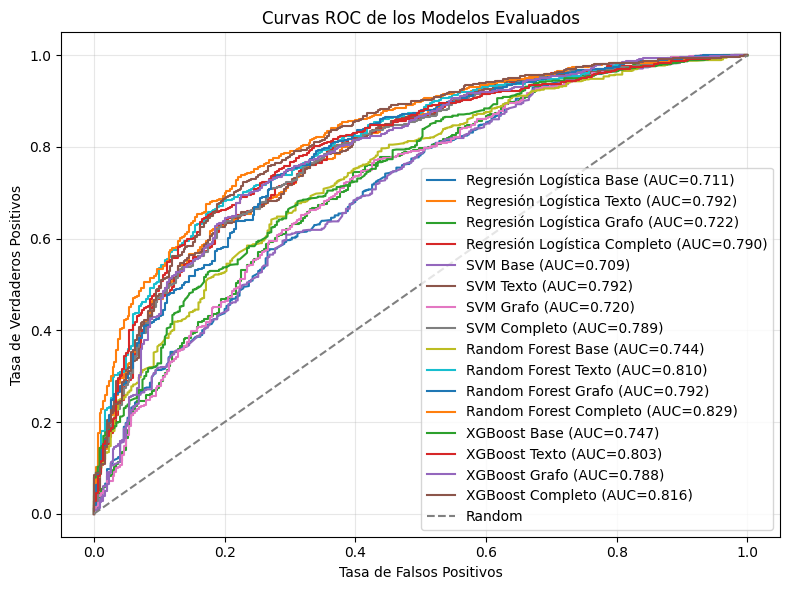

In [0]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

for name, y_true, y_score in curves:
    
    # ROC 
    fpr, tpr, _ = roc_curve(y_true, y_score)
    auc = roc_auc_score(y_true, y_score)
    
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

# Línea base (modelo random)
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random")

plt.xlabel("Tasa de Falsos Positivos")
plt.ylabel("Tasa de Verdaderos Positivos")
plt.title("Curvas ROC de los Modelos Evaluados")

plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

feature,importance_mean,importance_std
brief_title,0.06145855169293644,0.008929964096646929
closeness_norm,0.05404347246691001,0.008867857946760281
n_countries,0.02852807982849471,0.0082091082828522
primary_purpose,0.0223702009753708,0.004429537897691603
pagerank_norm,0.0164633768122876,0.005242166182774487
n_facilities,0.010471207422146179,0.004575372735557937
degree_total,0.008349045942889256,0.006833472156016814
community_size,0.007369203604843388,0.006216877047951346
allocation,0.006653118140666192,0.003695727024126208
n_sponsor_collaborator,0.005292532397125238,0.0032348361940377204


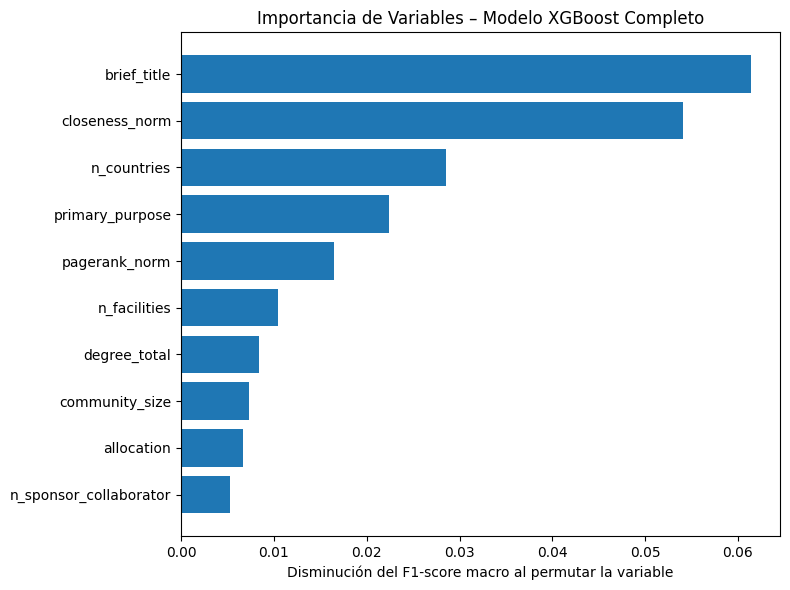

In [0]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.inspection import permutation_importance
from sklearn.metrics import make_scorer, f1_score

# Mejor modelo FULL
# XGBoost TABULAR + TEXT + GRAPH
pipe = best_xgb_full

# Dataset FULL
X_test = X_graph_text_test

# Métrica principal
scorer = make_scorer(f1_score, average="macro")

# Permutation Importance
perm_xgb_full = permutation_importance(
    estimator=pipe,
    X=X_test,
    y=y_test,
    scoring=scorer,
    n_repeats=10,
    random_state=42,
    n_jobs=1
)

# DataFrame resultados
pi_xgb_full_df = (
    pd.DataFrame({
        "feature": X_test.columns,
        "importance_mean": perm_xgb_full.importances_mean,
        "importance_std": perm_xgb_full.importances_std
    })
    .sort_values("importance_mean", ascending=False)
)

display(pi_xgb_full_df.head(20))

# Plot Top Variables
top_n = 10

plt.figure(figsize=(8, 6))

plt.barh(
    pi_xgb_full_df.head(top_n).iloc[::-1]["feature"],
    pi_xgb_full_df.head(top_n).iloc[::-1]["importance_mean"]
)

plt.xlabel("Disminución del F1-score macro al permutar la variable")
plt.title("Importancia de Variables – Modelo XGBoost Completo")

plt.tight_layout()
plt.show()